# Phase 01 — Data Collection

## Education and Income Inequality: A Cross-Country Panel Analysis

This notebook is the portfolio-facing artefact of Phase 01. It documents the
raw data layer of the project: the sources used, the coverage characteristics
of each source, and the constraints those characteristics impose on the
remaining phases.

- **Sources.** World Bank WDI (18 indicators plus country metadata) and
  UNDP Human Development Report (mean years of schooling).
- **Coverage window.** 1990–2023, all sovereign and near-sovereign states.
- **Scope reference.** [`docs/project_scope.md`](../docs/project_scope.md).

All heavy lifting — downloads, structural validation, coverage computation —
lives in the step scripts under `scripts/phase01_s*.py`. This notebook
reads the raw files those scripts produce and presents the results in
narrative form. It does **not** re-download; running it offline against a
populated `data/raw/` will succeed.

*Date: 2026-04-23*


## 2. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

# Make the project's src/ package importable from a notebook
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io_utils import read_csv_with_encoding_fallback

# Paths to the raw layer produced by Phase 01 step scripts
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
MANIFEST_PATH = RAW_DIR / "manifest.yaml"
WB_WDI_PATH   = RAW_DIR / "world_bank" / "wb_wdi.csv"
WB_META_PATH  = RAW_DIR / "world_bank" / "wb_country_metadata.csv"
HDR_PATH      = RAW_DIR / "undp_hdr" / "hdr_composite_indices.csv"

# Scope window
START_YEAR, END_YEAR = 1990, 2023
YEARS = list(range(START_YEAR, END_YEAR + 1))

# Fail fast with a helpful message if the raw layer has not been built yet
missing = [p for p in (MANIFEST_PATH, WB_WDI_PATH, WB_META_PATH, HDR_PATH) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Raw data files are missing. Run the Phase 01 step scripts first:\n"
        "  python scripts/phase01_s01_design_manifest.py\n"
        "  python scripts/phase01_s02_download_world_bank.py\n"
        "  python scripts/phase01_s04_download_undp_hdr.py\n"
        "  (Step 03 was absorbed into Step 02; see PROJECT_LOG.md)\n"
        f"Missing: {[str(p) for p in missing]}"
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Scope years  : {START_YEAR}-{END_YEAR} ({len(YEARS)} years)")
print("All raw files present.")


Project root : C:\Users\kotae\Documents\Portfolio\project\Project 4\education-inequality-analysis
Scope years  : 1990-2023 (34 years)
All raw files present.


## 3. Data Source Registry

The raw layer is defined by a machine-readable manifest at
`data/raw/manifest.yaml`. Every indicator code, source URL, and output
filename is declared there, so a fresh clone of the repository can regenerate
the entire raw layer from the step scripts alone.


In [2]:
with MANIFEST_PATH.open("r", encoding="utf-8") as f:
    manifest = yaml.safe_load(f)

print(f"Project  : {manifest['project']}")
print(f"Schema   : v{manifest['schema_version']}")
print(f"Coverage : {manifest['coverage']['start_year']}-{manifest['coverage']['end_year']}")
print(f"Sources  : {len(manifest['sources'])}\n")

for src_name, src in manifest["sources"].items():
    desc = (src.get("description") or "").strip()
    print(f"- {src_name}")
    print(f"    {desc}")
    if "indicators" in src:
        print(f"    indicators: {len(src['indicators'])}")


Project  : education-inequality-analysis
Schema   : v1
Coverage : 1990-2023
Sources  : 3

- world_bank_wdi
    World Bank World Development Indicators (includes UNESCO UIS mirror series SE.*)
    indicators: 18
- world_bank_metadata
    World Bank country metadata (region, income group, ISO-3 codes)
- undp_hdr
    UNDP Human Development Report — composite indices complete time series (HDR 2025)


## 4. World Bank Indicators

The World Bank WDI API is the single source for all numeric panel data in
this project. It supplies the analytical target (Gini), all structural and
economic controls, and — importantly — the mirrored UNESCO UIS education
series (the `SE.*` codes), which eliminates the need for a separate UNESCO
download pathway.

All 18 declared indicators were retrieved for 1990–2023 across every entity
WDI reports, producing a long-format file of ~163,000 rows.


In [3]:
wdi = pd.read_csv(WB_WDI_PATH)

print(f"WDI shape            : {wdi.shape}")
print(f"Unique indicators    : {wdi['declared_name'].nunique()}")
print(f"Unique entities      : {wdi['country_iso3'].nunique()}")
print(f"Year range           : {int(wdi['year'].min())}-{int(wdi['year'].max())}")

wdi.head(8)


WDI shape            : (162792, 8)
Unique indicators    : 18
Unique entities      : 261
Year range           : 1990-2023


,indicator_code,indicator_name,declared_name,country_iso3,country_iso2,country_name,year,value
0,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2023,NaN
1,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2022,NaN
2,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2021,NaN
3,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2020,NaN
4,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2019,NaN
5,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2018,NaN
6,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2017,NaN
7,SI.POV.GINI,Gini index,gini,AFE,ZH,Africa Eastern and Southern,2016,NaN


### Country metadata

The WB also exposes a country-level metadata endpoint — ISO-3 code, region,
income group, geographic coordinates. It is loaded separately and used
throughout the project to tell real countries apart from aggregate
categories such as *World* or *Sub-Saharan Africa*.

A subtlety: the World Bank marks aggregates with `region.id == "NA"`, which
`pandas.read_csv` silently converts to `NaN`. The filter therefore uses
`.notna()` rather than a string comparison.


In [4]:
meta = pd.read_csv(WB_META_PATH)

is_country = meta["region_id"].notna()
print(f"Total entities : {len(meta)}")
print(f"  Countries    : {int(is_country.sum())}")
print(f"  Aggregates   : {int((~is_country).sum())}")

# Build the canonical country set used throughout this notebook
WB_COUNTRY_SET = set(meta.loc[is_country, "country_iso3"].dropna())

print("\nIncome-group distribution (countries only):")
(
    meta.loc[is_country, "income_level_name"]
        .value_counts(dropna=False)
        .rename_axis("income_group")
        .to_frame("n_countries")
)


Total entities : 296
  Countries    : 217
  Aggregates   : 79

Income-group distribution (countries only):


,n_countries
income_group,
High income,86
Upper middle income,54
Lower middle income,50
Low income,25
Not classified,2


## 5. UNDP Human Development Report

The UNDP HDR publishes annual composite indices (HDI, IHDI, GII, GDI, PHDI)
alongside their components: life expectancy, expected and mean years of
schooling, and GNI per capita. For this project only **mean years of
schooling (`mys`)** is used, as an attainment-level complement to the WB's
flow-level enrolment rates.

### Two implementation notes

1. **Encoding.** HDR CSVs are published in Windows-1252, not UTF-8. The
   helper `src.io_utils.read_csv_with_encoding_fallback` transparently tries
   a sequence of encodings and reports which one succeeded.
2. **Vintage.** The HDR 2025 release (May 2025) is used because its time
   series covers 1990–2023 exactly, matching project scope. Earlier
   vintages stop in 2022.


In [5]:
hdr, enc_used = read_csv_with_encoding_fallback(HDR_PATH)

print(f"HDR shape            : {hdr.shape}")
print(f"Encoding used        : {enc_used}")
print(f"Key columns present  : {[c for c in ['iso3', 'country', 'hdicode', 'region'] if c in hdr.columns]}")

mys_cols = sorted(
    [c for c in hdr.columns if c.startswith('mys_') and c.split('_', 1)[1].isdigit()],
    key=lambda c: int(c.split('_', 1)[1]),
)
mys_years = [int(c.split('_', 1)[1]) for c in mys_cols]
print(f"mys columns          : {len(mys_cols)} (years {min(mys_years)}-{max(mys_years)})")

hdr[['iso3', 'country', 'region', 'hdicode', 'mys_1990', 'mys_2023']].head(8)


HDR shape            : (206, 1112)
Encoding used        : cp1252
Key columns present  : ['iso3', 'country', 'hdicode', 'region']
mys columns          : 34 (years 1990-2023)


,iso3,country,region,hdicode,mys_1990,mys_2023
0,AFG,Afghanistan,SA,Low,0.871962,2.514790
1,ALB,Albania,ECA,Very High,7.351565,10.175311
2,DZA,Algeria,AS,High,3.917092,7.416387
3,AND,Andorra,NaN,Very High,NaN,11.610000
4,AGO,Angola,SSA,Medium,NaN,5.956173
5,ATG,Antigua and Barbuda,LAC,Very High,NaN,11.647500
6,ARG,Argentina,LAC,Very High,8.122559,11.184582
7,ARM,Armenia,ECA,Very High,9.783419,11.344978


## 6. Coverage Analysis

The analytical usefulness of this panel hinges not on which variables we
have, but on how densely they overlap across country and year. Below is a
per-variable summary restricted to the 217 real countries and the 34-year
Scope window — giving 7,378 potential country-year cells per variable.


In [6]:
def wb_variable_long(wdi_df, declared_name, country_set, years):
    sub = wdi_df.loc[
        wdi_df['declared_name'] == declared_name,
        ['country_iso3', 'year', 'value'],
    ].copy()
    sub = sub.dropna(subset=['country_iso3', 'year'])
    sub['year'] = sub['year'].astype(int)
    sub = sub[sub['year'].between(years[0], years[-1])]
    sub = sub[sub['country_iso3'].isin(country_set)]
    return sub


def hdr_mys_long(hdr_df, country_set, years):
    mys_cols = [c for c in hdr_df.columns
                if c.startswith('mys_') and c.split('_', 1)[1].isdigit()]
    sub = hdr_df[['iso3'] + mys_cols].rename(columns={'iso3': 'country_iso3'})
    long = sub.melt(id_vars=['country_iso3'], var_name='col', value_name='value')
    long['year'] = long['col'].str.split('_', n=1).str[1].astype(int)
    long = long[long['year'].between(years[0], years[-1])]
    long = long[long['country_iso3'].isin(country_set)]
    return long.dropna(subset=['country_iso3'])[['country_iso3', 'year', 'value']]


def summarise(long_df, name, source, n_countries, n_years):
    non_null = int(long_df['value'].notna().sum())
    uniq = int(long_df.loc[long_df['value'].notna(), 'country_iso3'].nunique())
    total = n_countries * n_years
    return {
        'variable': name,
        'source': source,
        'non_null': non_null,
        'countries_with_data': uniq,
        'completeness_pct': round(100 * non_null / total, 1),
    }


rows = []
for ind in manifest['sources']['world_bank_wdi']['indicators']:
    long = wb_variable_long(wdi, ind['name'], WB_COUNTRY_SET, YEARS)
    rows.append(summarise(long, ind['name'], 'WB WDI',
                          len(WB_COUNTRY_SET), len(YEARS)))

mys_long = hdr_mys_long(hdr, WB_COUNTRY_SET, YEARS)
rows.append(summarise(mys_long, 'mean_years_schooling', 'UNDP HDR',
                      len(WB_COUNTRY_SET), len(YEARS)))

coverage = (
    pd.DataFrame(rows)
      .sort_values('completeness_pct', ascending=False)
      .reset_index(drop=True)
)
coverage


,variable,source,non_null,countries_with_data,completeness_pct
0,urban_population_pct,WB WDI,7378,217,100.0
1,population,WB WDI,7378,217,100.0
2,gdp_per_capita_usd,WB WDI,7014,214,95.1
3,gdp_per_capita_ppp,WB WDI,6597,199,89.4
4,agri_value_added_gdp,WB WDI,6218,206,84.3
5,unemployment_rate,WB WDI,6167,187,83.6
6,mean_years_schooling,UNDP HDR,6081,193,82.4
7,services_value_added_gdp,WB WDI,6074,205,82.3
8,inflation_cpi,WB WDI,5841,193,79.2
9,manu_value_added_gdp,WB WDI,5837,203,79.1


Two observations dominate this table:

1. **Gini is the binding constraint.** 30.0% country-year completeness,
   compared with 50–100% for every other variable. Any specification that
   requires Gini will inherit this density and land in the 2,000–3,000
   observation range already predicted by Scope v2 §6.2.
2. **Mean years of schooling is denser than every enrolment measure.** The
   HDR applies imputation across years and produces a near-complete series
   (82%); the raw UIS enrolment rates carry the gaps that developing-country
   household surveys typically produce.

Density alone is not enough, though. *When* the data is missing often
matters more than *how much* — the heatmap below reveals the shape.


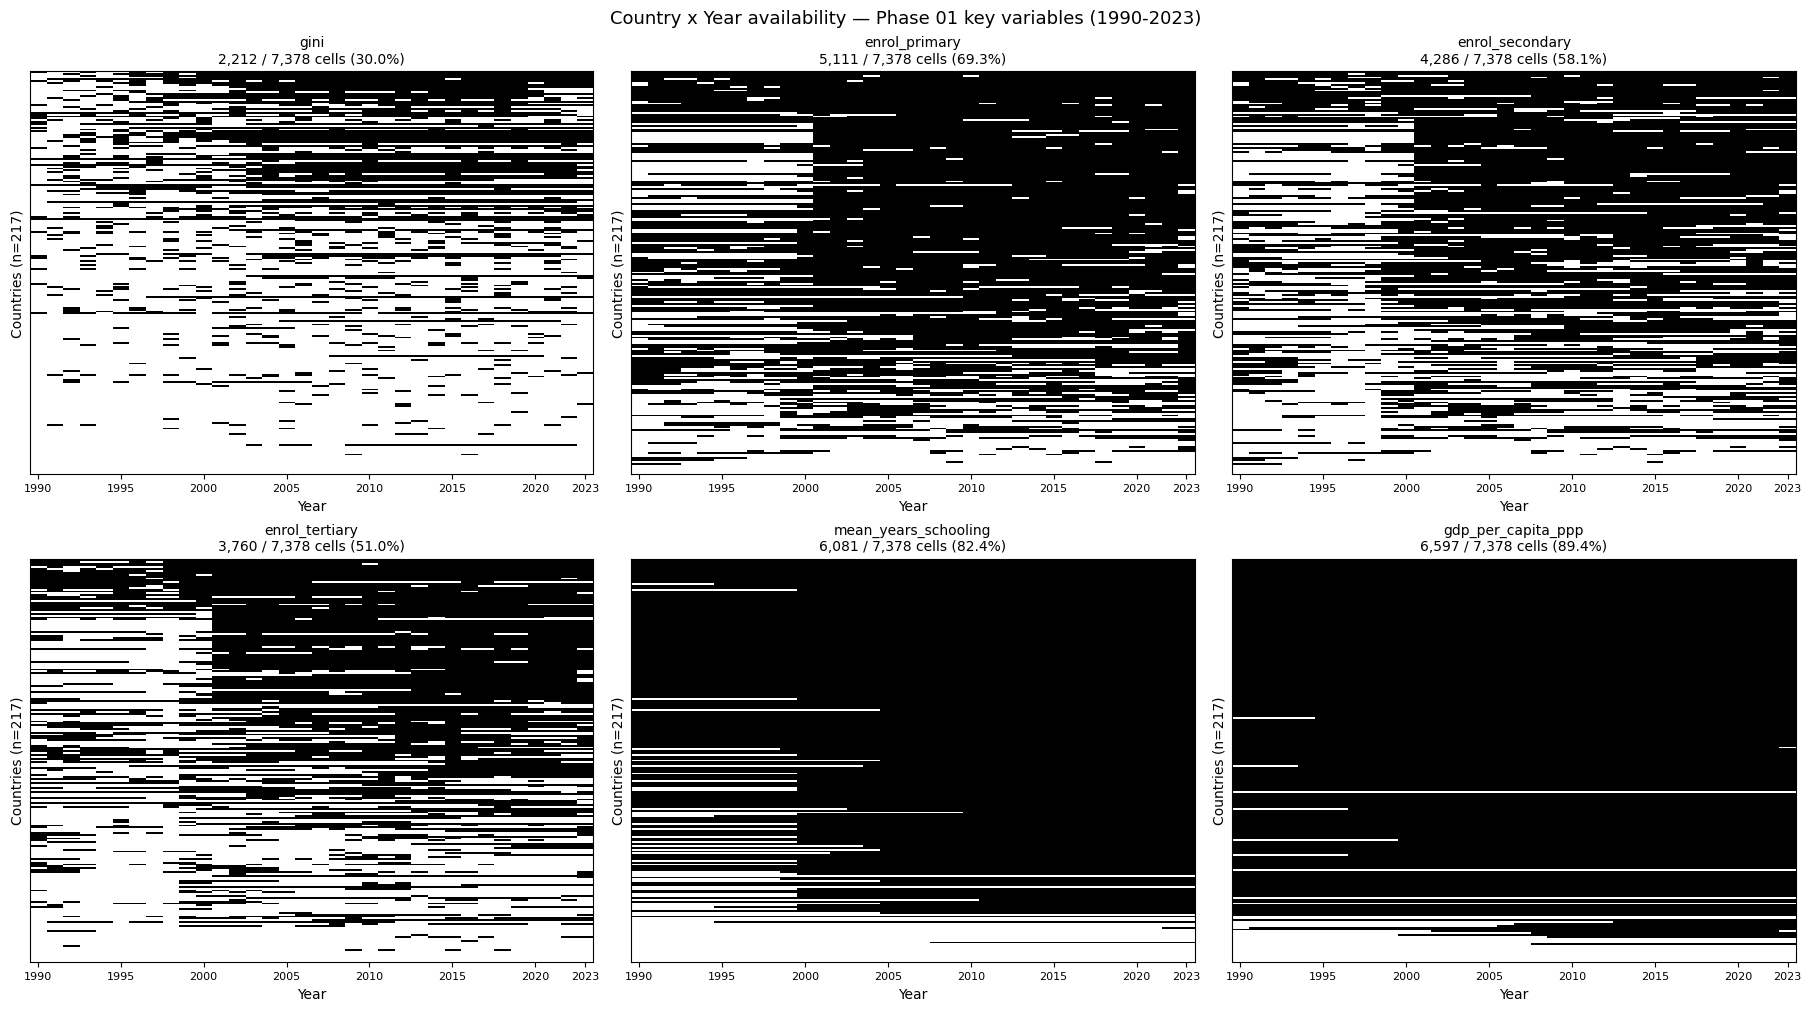

In [7]:
VIS_VARS = [
    ('gini',                  'wb'),
    ('enrol_primary',         'wb'),
    ('enrol_secondary',       'wb'),
    ('enrol_tertiary',        'wb'),
    ('mean_years_schooling',  'hdr'),
    ('gdp_per_capita_ppp',    'wb'),
]

vis_longs = {}
for name, src in VIS_VARS:
    if src == 'wb':
        vis_longs[name] = wb_variable_long(wdi, name, WB_COUNTRY_SET, YEARS)
    else:
        vis_longs[name] = mys_long

# Order countries by total presence across the six key variables
presence = {iso: 0 for iso in WB_COUNTRY_SET}
for long in vis_longs.values():
    non_null = long.dropna(subset=['value'])
    for iso, n in non_null.groupby('country_iso3').size().items():
        presence[iso] = presence.get(iso, 0) + int(n)
countries_ordered = sorted(WB_COUNTRY_SET, key=lambda c: (-presence[c], c))


def availability_matrix(long_df, countries, years):
    df = long_df.dropna(subset=['value']).copy()
    df['has'] = 1
    pivot = (
        df.pivot_table(index='country_iso3', columns='year',
                       values='has', aggfunc='max', fill_value=0)
          .reindex(index=countries, columns=years, fill_value=0)
          .astype(int)
    )
    return pivot.to_numpy()


fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (name, _src) in zip(axes.ravel(), VIS_VARS):
    mat = availability_matrix(vis_longs[name], countries_ordered, YEARS)
    present_pct = 100 * mat.sum() / mat.size
    ax.imshow(mat, aspect='auto', cmap='Greys',
              interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(
        f"{name}\n{int(mat.sum()):,} / {mat.size:,} cells ({present_pct:.1f}%)",
        fontsize=10,
    )
    ax.set_xlabel('Year')
    ax.set_ylabel(f'Countries (n={len(countries_ordered)})')
    ticks = [0, 5, 10, 15, 20, 25, 30, len(YEARS) - 1]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(YEARS[t]) for t in ticks], fontsize=8)
    ax.set_yticks([])

fig.suptitle(
    f'Country x Year availability — Phase 01 key variables ({START_YEAR}-{END_YEAR})',
    fontsize=13,
)
plt.show()


Three patterns are visible:

1. **Pre-2000 enrolment sparsity.** All three enrolment variables show a
   clear density jump around year 2000 — when many countries first started
   submitting standardised UIS returns. Phase 02 will need to decide
   whether to truncate the analytical window.
2. **Mean years of schooling and GDP are dense throughout.** Both series
   are near-complete for 1990–2023 across all 217 countries, including
   lower-income ones. HDR achieves this by imputation; WB's GDP per capita
   series is genuinely that broad.
3. **Gini is structurally sparse.** The scatter pattern within the Gini
   panel is not explained by country or year alone — it reflects the
   irregular timing of national household income surveys. Any analytical
   sample built on Gini will inherit this irregularity.


## 7. Source Reconciliation

Merging the WB and HDR layers requires that their country identifiers
align. The WB publishes ISO-3 codes for 217 real countries; the HDR 2025
file does so for 195 UN member states (after its own regional aggregates
are excluded — they carry `iso3` codes prefixed `ZZ`).


In [8]:
hdr_all_iso3 = hdr['iso3'].dropna().astype(str)
hdr_country_set = set(hdr_all_iso3[~hdr_all_iso3.str.startswith('ZZ')].unique())

intersect = WB_COUNTRY_SET & hdr_country_set
wb_only = WB_COUNTRY_SET - hdr_country_set
hdr_only = hdr_country_set - WB_COUNTRY_SET

print(f"WB countries    : {len(WB_COUNTRY_SET)}")
print(f"HDR countries   : {len(hdr_country_set)}")
print(f"Intersection    : {len(intersect)}")
print(f"WB-only         : {len(wb_only)}")
print(f"HDR-only        : {len(hdr_only)}")

wb_only_df = (
    meta.loc[meta['country_iso3'].isin(wb_only),
             ['country_iso3', 'country_name', 'region_name', 'income_level_name']]
        .sort_values('country_iso3')
        .reset_index(drop=True)
)
wb_only_df


WB countries    : 217
HDR countries   : 195
Intersection    : 195
WB-only         : 22
HDR-only        : 0


,country_iso3,country_name,region_name,income_level_name
0,ABW,Aruba,Latin America & Caribbean,High income
1,ASM,American Samoa,East Asia & Pacific,High income
2,BMU,Bermuda,North America,High income
3,CHI,Channel Islands,Europe & Central Asia,High income
4,CUW,Curacao,Latin America & Caribbean,High income
5,CYM,Cayman Islands,Latin America & Caribbean,High income
6,FRO,Faroe Islands,Europe & Central Asia,High income
7,GIB,Gibraltar,Europe & Central Asia,High income
8,GRL,Greenland,Europe & Central Asia,High income
9,GUM,Guam,East Asia & Pacific,High income


All 195 HDR iso3s are a strict subset of the 217 WB countries — there is
no HDR-only entity to reconcile. The 22 WB-only entries are all
non-sovereign territories or special administrative regions (Aruba,
Bermuda, Channel Islands, Puerto Rico, Macao SAR, and similar), which the
HDR excludes by design.

The practical consequence: whether the final analytical panel includes
these 22 is a Phase 02 design decision, not a reconciliation problem.
Keeping them requires handling specifications that need `mys` differently
from those that do not; dropping them simplifies the merge and trims the
sample by at most 22 countries, all of which are high- or upper-middle
income (a selection bias worth stating explicitly in Phase 07).


## 8. Implications for Phase 02

Phase 01 establishes the raw layer; the following findings are direct
inputs to the Phase 02 cleaning, integration, and missingness strategy:

1. **Gini is the binding constraint.** 30% country-year completeness
   means any specification requiring Gini will land in the 2,000–3,000
   observation range predicted by Scope v2 §6.2.
2. **Pre-2000 enrolment data is sparse and structurally different.** The
   analytical-sample decision should consider either truncating to
   2000–2023 or leaning on mean years of schooling (which is dense
   throughout) as the primary educational-attainment variable.
3. **22 non-sovereign territories lack HDR coverage.** Dropping them is
   the simpler design; retaining them requires branching handling for
   `mys`-requiring vs. `mys`-optional specifications.
4. **All 18 WB indicators and `mys` are available for the full Scope
   window.** No variable needs to be dropped for data-availability reasons
   alone.
5. **`SE.SEC.ENRR.MA` (male secondary enrolment) is stable.** The
   transient API timeouts observed during Step 01 validation did not
   recur at bulk-download time in Step 02 — 5,505 non-null observations
   were retrieved cleanly.


## 9. Conclusion

Phase 01 delivers a reproducible, auditable raw data layer:

- **One manifest** (`data/raw/manifest.yaml`) declares every variable,
  source, and output path.
- **One script per step** (`phase01_s01` through `phase01_s05`) rebuilds
  the raw layer from a clean clone given only network access.
- **One notebook** (this file) documents what was collected and what it
  implies for downstream analysis.

### Limitations acknowledged at this stage

- **Observational cross-country data only.** A constraint set by Scope v2
  and not relaxed here; causal claims will be bounded accordingly in
  Phase 07.
- **Gini measurement heterogeneity.** The WB Gini series concatenates
  different national survey methodologies. This is addressed qualitatively
  in Phase 07 and partially absorbed by the fixed-effects specifications
  planned in Phase 05.
- **22 countries missing from HDR** — documented in §7.
- **Pre-2000 enrolment sparsity** — documented in §6.

### Next

Phase 02 — Data Cleaning & Integration. Produces the analytical panel
(`data/processed/panel.csv`) by joining WB and HDR, canonicalising
country identifiers, and making explicit decisions about the Gini-driven
sample reduction and the enrolment-sparsity window.
